# Weight Estimation - Improvements

**Author:** Xián Novoa Gutiérrez  
**Project:** Poultry Vision Monitoring  
**Repository:** https://github.com/xiannovoa/poultry-vision-monitoring

## Introduction

In this notebook, we build upon the baseline model for chicken weight estimation from images.

The baseline results showed that, although the model is able to learn meaningful patterns, its performance is still limited (MAE = 283 grams), and it struggles to generalize well to unseen data.

The goal of this notebook is to improve the model in a controlled and measurable way by introducing incremental changes to the data processing, model architecture, and training strategy.

All improvements will be evaluated using the same metric (MAE in grams), allowing a direct comparison with the baseline.

## 1. Dataset
https://huggingface.co/datasets/xiannovoa/poultry-weight-dataset

This part is identical to the one in *01_weight_estimation_baseline*.

In [1]:
from datasets import load_dataset, Image
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
ROOT = Path.cwd().resolve()

while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATASET_PATH = ROOT / "data/03_final/broiler_weight_dataset"

assert DATASET_PATH.exists(), f"Dataset no encontrado en {DATASET_PATH}"

In [3]:
dataset = load_dataset(
    "csv",
    data_files={"train": str(DATASET_PATH / "labels.csv")}
)

**Important**: The image paths in the CSV are relative (e.g., "images/img_00042.jpg").
We convert them to absolute paths so that the dataset can correctly load images from disk.

In [4]:
def add_full_path(example):
    example["image"] = str(DATASET_PATH / example["image"])
    return example

dataset = dataset.map(add_full_path)

In [5]:
dataset = dataset.cast_column("image", Image())

In [6]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'weight'],
        num_rows: 4761
    })
})


Weight: 1243


(np.float64(-0.5), np.float64(1839.5), np.float64(4079.5), np.float64(-0.5))

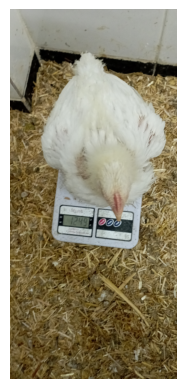

In [7]:
sample = dataset["train"][42]

print("Weight:", sample["weight"])

plt.imshow(sample["image"])
plt.axis("off")

## 2. Data Augmentation

To improve the model’s ability to generalize, we introduce data augmentation techniques applied to the training set.

These transformations generate slight variations of the input images, helping the model become more robust to changes in orientation and lighting conditions.

The validation set remains unchanged to ensure a fair evaluation.

In [8]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

The applied augmentations introduce small variations in the input images. *RandomHorizontalFlip* simulates different viewing orientations, *RandomRotation* applies slight rotations to account for camera or subject variability, and *ColorJitter* introduces minor changes in brightness and contrast to mimic different lighting conditions.

## 3. Data Preparation for Training (PyTorch)

We convert the dataset into a PyTorch-compatible format.

This includes:
- applying image transformations
- creating a custom Dataset
- preparing data for batching

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader

### Image Transformations

We apply different transformations for training and validation.

Training data includes augmentation, while validation data remains unchanged.

### Custom PyTorch Dataset

We wrap our dataset into a Pytorch Dataset to:

- apply transformations
- return [image, weight] pairs

One of the main conclusions of *01_weight_estimation_baseline.ipynb* was that **target normalization** helped to achieve better results. So we use the final normalized class.

In [10]:
class NormalizedPoultryDataset(Dataset):
    def __init__(self, hf_dataset, transform=None, mean=0.0, std=1.0):
        self.dataset = hf_dataset
        self.transform = transform
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        image = sample["image"]
        weight = sample["weight"]

        if weight is None:
            raise ValueError(f"Missing weight at index {idx}")

        if self.transform:
            image = self.transform(image)

        weight = (float(weight) - self.mean) / self.std
        weight = torch.tensor(weight, dtype=torch.float32)

        return image, weight

## 4. Train / Validation Split

To properly evaluate the model, we split the dataset into training and validation sets.

This allows us to:
- train the model on one subset
- evaluate its performance on unseen data

In [11]:
from torch.utils.data import random_split

full_dataset = dataset["train"]

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

print(f"Train size: {len(train_subset)}")
print(f"Validation size: {len(val_subset)}")

Train size: 3808
Validation size: 953


### Target Normalization

We normalize the target variable (weight) to stabilize training.

The model is trained on normalized values, and predictions are later converted back to the original scale for evaluation.

In [12]:
import numpy as np

train_weights = [sample["weight"] for sample in train_subset]

mean_weight = np.mean(train_weights)
std_weight = np.std(train_weights)

print(f"Mean weight: {mean_weight:.2f}")
print(f"Std weight: {std_weight:.2f}")

Mean weight: 469.96
Std weight: 390.37


### PyTorch Datasets (Train and Validation)

We wrap both subsets into our custom PyTorch Dataset.

Different transformations are applied:
- training set => data augmentation
- validation set => NO augmentation

In [13]:
train_dataset = NormalizedPoultryDataset(
    train_subset,
    transform=train_transform,
    mean=mean_weight,
    std=std_weight
)

val_dataset = NormalizedPoultryDataset(
    val_subset,
    transform=val_transform,
    mean=mean_weight,
    std=std_weight
)

### DataLoaders

We create separate DataLoaders:

- Training loader → shuffled
- Validation loader → not shuffled

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

## 5. Model and Training Setup

We define an improved Convolutional Neural Network (CNN) for regression.

Compared to the baseline, this model includes:
- increased capacity (more channels)
- batch normalization for training stability
- dropout for regularization

In [15]:
import torch.nn as nn
import torch.nn.functional as F

In [16]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.dropout = nn.Dropout(p=0.3)
        self.fc2 = nn.Linear(256, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x.squeeze(1)

Compared to the baseline model, this architecture **increases the number of channels** to improve representational capacity, **incorporates batch normalization** to stabilize training, and **introduces dropout** to reduce overfitting.

In [17]:
device = torch.device("cpu")

model = ImprovedCNN().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## 6. Training with Validation

We train the model using normalized targets and monitor both training and validation loss.

This allows us to assess how well the model generalizes to unseen data.

In [18]:
num_epochs = 20

for epoch in range(num_epochs):

    # TRAIN
    model.train()
    train_loss = 0.0

    for images, weights in train_loader:
        images = images.to(device)
        weights = weights.to(device)

        optimizer.zero_grad()

        outputs = model(images).squeeze()
        loss = criterion(outputs, weights)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, weights in val_loader:
            images = images.to(device)
            weights = weights.to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, weights)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

Epoch [1/20] - Train Loss: 422.9942 - Val Loss: 1.0255
Epoch [2/20] - Train Loss: 0.9821 - Val Loss: 0.9727
Epoch [3/20] - Train Loss: 0.9448 - Val Loss: 0.9253
Epoch [4/20] - Train Loss: 0.8847 - Val Loss: 0.8775
Epoch [5/20] - Train Loss: 0.8247 - Val Loss: 0.7941
Epoch [6/20] - Train Loss: 0.7823 - Val Loss: 0.7978
Epoch [7/20] - Train Loss: 0.7678 - Val Loss: 0.7181
Epoch [8/20] - Train Loss: 0.7388 - Val Loss: 0.6866
Epoch [9/20] - Train Loss: 0.7171 - Val Loss: 0.6932
Epoch [10/20] - Train Loss: 0.6779 - Val Loss: 0.6601
Epoch [11/20] - Train Loss: 0.6696 - Val Loss: 0.6540
Epoch [12/20] - Train Loss: 0.6524 - Val Loss: 0.6248
Epoch [13/20] - Train Loss: 0.6556 - Val Loss: 0.6074
Epoch [14/20] - Train Loss: 0.6501 - Val Loss: 0.6251
Epoch [15/20] - Train Loss: 0.6278 - Val Loss: 0.6245
Epoch [16/20] - Train Loss: 0.6032 - Val Loss: 0.5862
Epoch [17/20] - Train Loss: 0.5968 - Val Loss: 0.5420
Epoch [18/20] - Train Loss: 0.5743 - Val Loss: 0.5599
Epoch [19/20] - Train Loss: 0.5905 

### Evaluation (MAE in grams)

We compute Mean Absolute Error (MAE) in the original scale (grams). This gives a more interpretable metric.

In [19]:
model.eval()
mae = 0.0

with torch.no_grad():
    for images, weights in val_loader:
        images = images.to(device)
        weights = weights.to(device)

        outputs = model(images).squeeze()

        # Denormalize
        preds = outputs * std_weight + mean_weight
        targets = weights * std_weight + mean_weight

        mae += torch.abs(preds - targets).sum().item()

mae /= len(val_dataset)

print(f"Validation MAE: {mae:.2f} grams")

Validation MAE: 186.82 grams


### Example Prediction

We visualize a prediction and compare it to the real weight.

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

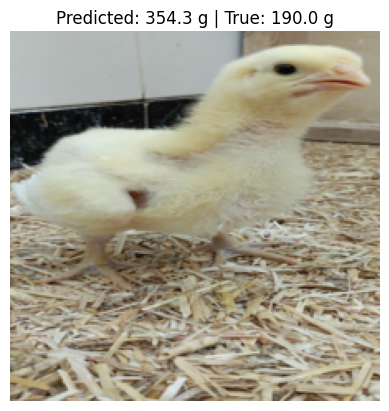

In [20]:
sample = val_dataset[0]

image, weight_norm = sample

model.eval()
with torch.no_grad():
    pred_norm = model(image.unsqueeze(0).to(device)).squeeze()

pred_weight = pred_norm.item() * std_weight + mean_weight
true_weight = weight_norm.item() * std_weight + mean_weight

img = image.permute(1, 2, 0)

plt.imshow(img)
plt.title(f"Predicted: {pred_weight:.1f} g | True: {true_weight:.1f} g")
plt.axis("off")

**The improved model shows a clear performance gain over the baseline**, reducing the MAE from approximately 283 grams to around 187 grams. 

Data augmentation and increased model capacity contribute to better generalization, while target normalization ensures stable and efficient training. 

Although the model captures more meaningful visual patterns, prediction errors are still present, indicating that further improvements may require more advanced architectures or better control over the input data.